In [1]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect, minimize
import pandas as pd
import conductivity_paper as cd
from scipy.optimize import brute
from matplotlib.ticker import MaxNLocator

# Determining the Best Cation Ratio for Three-Salt System Experiments

## Load the data

In [2]:
data = pd.read_csv("./Data/Three_salts_cation_ratio.csv")
NaCl_conc_raw = data["NaCl_conc"]
CaCl2_conc_raw = data["CaCl2_conc"]
LaCl3_conc_raw = data["LaCl3_conc"]

# number of data points
ndata = len(NaCl_conc_raw)

print(data)

   NaCl_conc  CaCl2_conc  LaCl3_conc
0          1           1           2
1          2           2           4
2          3           3           6
3          4           4           8
4          5           5          10
5          6           6          12
6          7           7          14
7          8           8          16
8          9           9          18
9         10          10          20


## MSA Transport model constants in SI units

In [3]:
# temperature in K
temp = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
diffusion_coeff = [Diff_La, Diff_Ca, Diff_Na, Diff_Cl] 

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
valency = [z_La, z_Ca, z_Na, z_Cl]

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
diameter = [sigma_La, sigma_Ca, sigma_Na, sigma_Cl]

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_La_Ca_Na_Cl = [lambda_0_La_mol, lambda_0_Ca_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

## Variant Shedlovsky model constants

In [4]:
# solvent viscosity in poise
eta_shed = 8.903*10**(-3)

# limiting equivalent conductivity of salts in cm^2.Siemen.equiv^(-1)
lambda_0_NaCl = 126.45 
lambda_0_CaCl2 = 135.85
lambda_0_LaCl3 = 145.9

# limiting equivalent conductivity of ions in cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 
lambda_0_Ca = 59.5
lambda_0_La = 69.7
lambda_0_Cl = 76.35

# distance from an ion within which no other ion can penetrate in cm
a_NaCl = 4*10**(-8)
a_CaCl2 = 4.31*10**(-8)
a_LaCl3 = 4.9*10**(-8)

## Validate the models with two-salt data

In [5]:
validation_data = pd.read_csv("./Data/NaCl_LaCl3_rearranged.csv")
NaCl_conc22 = validation_data["NaCl conc2"]
LaCl3_conc22 = validation_data["LaCl3 conc2"]
cond_exp_raw = validation_data["Cal bulk cond2"]

# number of data points
ndata_valid = len(cond_exp_raw)

# convert the conductivity from micro Siemen per cm to milli Siemen per cm
cond_exp = [cond_exp_raw[i]/1000 for i in range(ndata_valid)]

# diffusion coefficients, valencies, and hard sphere diameters of the two salts system
diffusion_coeff_2 = [Diff_La, Diff_Na, Diff_Cl]
valency_2 = [z_La, z_Na, z_Cl]
diameter_2 = [sigma_La, sigma_Na, sigma_Cl]
lambda_0_La_Na_Cl = [lambda_0_La_mol, lambda_0_Na_mol, lambda_0_Cl_mol]
a = (a_NaCl + a_LaCl3)/2

# evaluate the salts concentration in mM using the cation ratio
conc_NaCl_msa = [6*NaCl_conc_raw[i] for i in range(ndata)]

# evaluate the salts concentration in M using the cation ratio
conc_NaCl_shed = [conc_NaCl_msa[i]*10**(-3) for i in range(ndata)]
conc_LaCl3_shed = [LaCl3_conc_raw[i]*10**(-3) for i in range(ndata)]

# calculate the individual salt conductivity using the variant Shedlovsky model
variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a, z_Na, z_Cl, 
                             lambda_0_Na, lambda_0_Cl)
variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a, z_La, z_Cl, 
                             lambda_0_La, lambda_0_Cl)

# calculate the bulk conductivity using the variant Shedlovsky model
variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_LaCl3[i] for i in range(ndata)] 

# calculate the bulk conductivity using the MSA transport model
msa_cond = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, temp, eta_msa, epsilon, lambda_0_La_Na_Cl, LaCl3_conc_raw, conc_NaCl_msa)

sse = sum((msa_cond[i] - cond_exp[i])**2 for i in range(ndata))

err = [(msa_cond[i] - cond_exp[i])/msa_cond[i] for i in range(ndata)]
err_abs = [np.abs(err[i]) for i in range(ndata)]
print("MAPE",np.mean(err_abs))

print("The variant Shedlovsky:\n",variant_shed_cond)
print("MSA transport:\n",msa_cond)
print("SSE",sse)

Relaxation correction: [-0.17116259 -0.02670757 -0.09893508]
Hydrodynamic correction: [-0.40925151 -0.19314246 -0.1171157 ]
omega_bar: 293668709070.8091
Alpha: [0.0, 242876329097.13528, 388092787538.26306]
Mew: [0.5        0.16666667 0.33333333]
Transport number: [0.25596141 0.18387319 0.5601654 ]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.69629658 -0.98749428 -0.23296339]
 [ 0.78711213  1.6842391  -1.40795025]
 [ 0.51673602  0.63912188  1.0534202 ]]
MAPE 0.020757235331234615
The variant Shedlovsky:
 [1.4836887591090644, 2.864356235130524, 4.188158227157195, 5.470507290133768, 6.719897842857053, 7.941830542973447, 9.140197040213245, 10.317912087125002, 11.477248024580849, 12.62003003909751]
MSA transport:
 [1.4308664142594345, 2.7320048114702002, 3.965863844897389, 5.152524109650507, 6.30276307653146, 7.423402745461817, 8.519172355316185, 9.593548816540238, 10.649196609867742, 11.688221935056538]
SSE 0.4520929863589307


## Solve the Optimization Problem

### Validation of cation ratio with two-salt data

In [6]:
# create the objective function of the optimization problem
def SSE_validation(cation_ratio):
    """
    Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

    Argument:
        cation_ratio: cation ratio of the salt"""

    # evaluate the salts concentration in mM using the cation ratio
    conc_NaCl = [cation_ratio*NaCl_conc_raw[i] for i in range(ndata)]

    # evaluate the salts concentration in M using the cation ratio
    conc_NaCl_shed = [conc_NaCl[i]*10**(-3) for i in range(ndata)]
    conc_LaCl3_shed = [LaCl3_conc_raw[i]*10**(-3) for i in range(ndata)]

    # calculate the individual salt conductivity using the variant Shedlovsky model
    variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a, z_Na, z_Cl, 
                                 lambda_0_Na, lambda_0_Cl)
    variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a, z_La, z_Cl, 
                                 lambda_0_La, lambda_0_Cl)

    # calculate the bulk conductivity using the variant Shedlovsky model
    variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_LaCl3[i] for i in range(ndata)]

    # calculate the bulk conductivity using the MSA transport model
    msa_cond = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, temp, eta_msa, epsilon, lambda_0_La_Na_Cl, LaCl3_conc_raw, conc_NaCl)

    # calculate the sum of squared errors between the variant Shedlovsky and MSA transport models
    sse = sum((msa_cond[i] - cond_exp[i])**2 for i in range(ndata))
    
    return sse

In [7]:
# Define bounds and step size for integers
ranges = (slice(1, 11, 1),)

# Run brute-force grid search
result = brute(SSE_validation, ranges=ranges, finish=None)

# Output
print("Best solution found for the cation ratio is:", result)
print("Objective value at best solution:", SSE_validation(result))

Relaxation correction: [-0.12637798 -0.01308509 -0.11019328]
Hydrodynamic correction: [-0.36243161 -0.17069429 -0.10443014]
omega_bar: 249407449467.97238
Alpha: [0.0, 296713649948.1031, 372366303979.31903]
Mew: [0.69230769 0.03846154 0.26923077]
Transport number: [0.41730337 0.04996255 0.53273408]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.44715366 -0.45169903 -0.31313326]
 [ 0.67150534  3.76294459 -2.32471958]
 [ 0.44084061  0.62394828  1.1373026 ]]
Relaxation correction: [-0.13744596 -0.01647846 -0.10720408]
Hydrodynamic correction: [-0.37274898 -0.17563275 -0.10724013]
omega_bar: 260788916222.98755
Alpha: [0.0, 280185123994.9613, 378474712351.47736]
Mew: [0.64285714 0.07142857 0.28571429]
Transport number: [0.37058471 0.08873811 0.54067718]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.50778913 -0.58944861 -0.27849707]
 [ 0.69964128  2.68345218 -1.89174574]
 [ 0.45931175  0.65539633  1.09955484]]
Relaxation correction: [-0.14726542 -0.01947212 

## Determine the optimal concentrations for model discrimination in future three-salt experiments

In [8]:
# shedlovsky constants
a_Na_Ca_La = (a_NaCl + a_CaCl2 + a_LaCl3)/3

In [9]:
def three_salts_conc(LaCl3_conc, NaCl_conc, ionic_strength, fig_name):
    """
    Calculates the concentration of CaCl2 and the prediction difference between the Variant Shedlovsky and MSA models

    Arguments:
        LaCl3_conc: list or Pandas series of the concentration of LaCl3 in mM
        NaCl_conc: list or Pandas series of the concentration of NaCl in mM
        ionic_strength: int or float of the desired ionic strength of the three-salt solution

    Returns:
        residuals_percent: list of the prediction difference between the Variant Shedlovsky and MSA models
    """
    na_conc_plot = []
    la_conc_plot = []
    ca_conc_plot = []
    
    # save the results
    residuals_percent = []
    
    for conc_na in NaCl_conc:
        for conc_la in LaCl3_conc:
            conc_ca = (2 * ionic_strength - conc_na * (z_Na**2 + z_Cl**2) - conc_la * z_La * (z_La + z_Cl**2)) / (z_Ca * (z_Ca + z_Cl**2))
            conc_list = [conc_na, conc_ca, conc_la]
            
            print("The concentration of NaCl is:",conc_na)
            print("The concentration of LaCl3 is:",conc_la)
            print("The concentration of CaCl2 is:",conc_ca)

            if all(conc_species >= 1 for conc_species in conc_list):
                # append the species concentration to their respective list
                na_conc_plot.append(conc_na)
                la_conc_plot.append(conc_la)
                ca_conc_plot.append(conc_ca)

                # calculate the species ionic strength
                ionic_str_na = 0.5 * conc_na * z_Na**2
                ionic_str_la = 0.5 * conc_la * z_La**2
                ionic_str_ca = 0.5 * conc_ca * z_Ca**2
                ionic_str_cl = 0.5 * (z_Na * conc_na + z_Ca * conc_ca + z_La * conc_la) * z_Cl**2
                # print("The ionic strength of Na+ is:",ionic_str_na)
                # print("The ionic strength of La3+ is:",ionic_str_la)
                # print("The ionic strength of Ca2+ is:",ionic_str_ca)
                # print("The ionic strength of Cl- is:",ionic_str_cl)
                
                # evaluate the salts concentration in M using the cation ratio
                conc_NaCl_shed = [conc_na * 10**(-3)]
                conc_CaCl2_shed = [conc_ca * 10**(-3)]
                conc_LaCl3_shed = [conc_la * 10**(-3)]
        
                # calculate the individual salt conductivity using the variant Shedlovsky model
                variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a_Na_Ca_La, z_Na, z_Cl, 
                                             lambda_0_Na, lambda_0_Cl)
                variant_shed_cond_CaCl2 = cd.variant_shedlovsky(conc_CaCl2_shed, temp, epsilon, eta_shed, lambda_0_CaCl2, a_Na_Ca_La, z_Ca, z_Cl, 
                                             lambda_0_Ca, lambda_0_Cl)
                variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a_Na_Ca_La, z_La, z_Cl, 
                                             lambda_0_La, lambda_0_Cl)
            
                # get the number of data
                ndata_all = len(variant_shed_cond_NaCl)
            
                # calculate the bulk conductivity using the variant Shedlovsky model
                variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_CaCl2[i] + variant_shed_cond_LaCl3[i] for i in range(ndata_all)]
            
                # calculate the bulk conductivity using the MSA transport model
                msa_cond = cd.msa_transport(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon, lambda_0_La_Ca_Na_Cl, 
                                            [conc_la], [conc_ca], [conc_na])
        
                # mean of the predictions which may be treated as data
                mean_cond_pred = [(msa_cond[i] + variant_shed_cond[i])/2 for i in range(ndata_all)]
            
                # calculate the residuals between the MSA transport and variant Shedlovksy models
                residuals = [variant_shed_cond[i] - msa_cond[i] for i in range(ndata_all)]
                residuals_per = [100 * residuals[i] / msa_cond[i] for i in range(ndata_all)]
            
                # calculate the mean absolute percent error
                abs_residuals_per = [np.abs(residuals_per[i]) for i in range(ndata_all)]
                mean_abs_residuals_per = np.mean(abs_residuals_per)

                print(f"The MAPE is of {(conc_na, conc_la)}", mean_abs_residuals_per)
                
                residuals_percent.append([mean_abs_residuals_per])
            else:
                na_conc_plot.append(conc_na)
                la_conc_plot.append(conc_la)
                ca_conc_plot.append(np.nan)
                residuals_percent.append([np.nan])

    # plot the model difference results
    residuals_percent_array = np.asarray(residuals_percent)

    # X and Y axis labels
    x_label = "Concentration of Na$\mathbf{^{+}} (mM)$"
    y_label = "Concentration of La$\mathbf{^{3+}} (mM)$"
    data_res = np.zeros((len(residuals_percent_array), 3))
    data_res[:, 0] = na_conc_plot
    data_res[:, 1] = la_conc_plot
    data_res[:, 2] = residuals_percent_array[:, 0]

    plot_heatmap(data_res, y_label, x_label, "Model Prediction Difference (%)", fig_name)

    # plot the salt concentration results
    data_conc = np.zeros((len(ca_conc_plot), 3))
    data_conc[:, 0] = na_conc_plot
    data_conc[:, 1] = la_conc_plot
    data_conc[:, 2] = ca_conc_plot
    
    plot_heatmap(data_conc, y_label, x_label, "Concentration of Ca$\mathbf{^{2+}} (mM)$", f"{fig_name}_conc")

In [10]:
# # Make heat map
# def plot_heatmap(data, y_label, x_label, colorbar_label, figure_name):
#     # set heatmap x,y ranges
#     x_tick_labels_0 = np.sort(np.unique(data[:, 0]))
#     y_tick_labels_0 = np.sort(np.unique(data[:, 1]))[::-1]

#     x_tick_labels = [int(x_tick_labels_0[i]) for i in range(len(x_tick_labels_0))]
#     y_tick_labels = [int(y_tick_labels_0[i]) for i in range(len(y_tick_labels_0))]

#     # optimality-values
#     opt_vals = np.asarray(data[:, 2]).reshape(len(x_tick_labels), len(y_tick_labels))

#     # Plot the colormap
#     fig = plt.figure()

#     # Plotting options
#     ax = fig.add_subplot(111)
#     params = {"mathtext.default": "regular"}
#     plt.rcParams.update(params)

#     # Plotting data
#     ax.set_yticks(range(len(y_tick_labels)))
#     ax.set_yticklabels(y_tick_labels)
#     ax.set_ylabel(y_label, fontsize=16.5, fontweight='bold')
#     ax.set_xticks(range(len(x_tick_labels)))
#     ax.set_xticklabels(x_tick_labels)
#     ax.set_xlabel(x_label, fontsize=16.5, fontweight='bold')
#     ax.xaxis.set_major_locator(MaxNLocator(nbins=9))
#     ax.yaxis.set_major_locator(MaxNLocator(nbins=9))
#     plt.xticks(fontsize=16.5)
#     plt.yticks(fontsize=16.5)
#     im = ax.imshow(opt_vals.T, cmap=plt.cm.hot_r)
#     ba = plt.colorbar(im)
#     ba.set_label(colorbar_label, fontsize=16.5, fontweight='bold')
#     ba.ax.tick_params(labelsize=16.5)
#     plt.tight_layout()
#     plt.savefig(f"{figure_name}_three_salts_heat.png")
#     plt.show()

In [11]:
# Make heat map
def plot_heatmap(data, y_label, x_label, colorbar_label, figure_name):
    # set heatmap x,y ranges
    x_tick_labels_0 = np.sort(np.unique(data[:, 0]))
    y_tick_labels_0 = np.sort(np.unique(data[:, 1]))[::-1]

    x_tick_labels = [int(x) for x in x_tick_labels_0]
    y_tick_labels = [int(y) for y in y_tick_labels_0]

    # reshape values
    opt_vals = data[:, 2].reshape(len(x_tick_labels), len(y_tick_labels))

    # create figure
    fig, ax = plt.subplots()

    params = {"mathtext.default": "regular"}
    plt.rcParams.update(params)

    # colormap with solid gray for NaN
    cmap = plt.cm.hot_r.copy()
    cmap.set_bad(color='lightgray')

    # plot heatmap
    im = ax.imshow(opt_vals.T, cmap=cmap)

    # ticks and labels
    ax.set_yticks(range(len(y_tick_labels)))
    ax.set_yticklabels(y_tick_labels)
    ax.set_ylabel(y_label, fontsize=16.5, fontweight='bold')

    ax.set_xticks(range(len(x_tick_labels)))
    ax.set_xticklabels(x_tick_labels)
    ax.set_xlabel(x_label, fontsize=16.5, fontweight='bold')

    ax.xaxis.set_major_locator(MaxNLocator(nbins=9))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=9))

    plt.xticks(fontsize=16.5)
    plt.yticks(fontsize=16.5)

    # colorbar
    cbar = plt.colorbar(im)
    cbar.set_label(colorbar_label, fontsize=16.5, fontweight='bold')
    cbar.ax.tick_params(labelsize=16.5)

    plt.tight_layout()
    plt.savefig(f"{figure_name}_three_salts_heat.png")
    plt.show()

### 50 mM Ionic Strength

The concentration of NaCl is: 1
The concentration of LaCl3 is: 9
The concentration of CaCl2 is: -1.6666666666666667
The concentration of NaCl is: 1
The concentration of LaCl3 is: 8
The concentration of CaCl2 is: 0.3333333333333333
The concentration of NaCl is: 1
The concentration of LaCl3 is: 7
The concentration of CaCl2 is: 2.3333333333333335
Relaxation correction: [-0.09547004 -0.03787809 -0.00984675 -0.08218058]
Hydrodynamic correction: [-0.24638383 -0.1947205  -0.11546729 -0.07221905]
omega_bar: 247506659560.32922
Alpha: [0.0, 185817594865.33917, 315583157007.6054, 363032203089.45233]
Mew: [0.63       0.09333333 0.01       0.26666667]
Transport number: [0.38266242 0.07253483 0.01309002 0.53171273]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.44468591 -0.56170106 -0.26102938 -0.37750181]
 [ 1.12911689  3.4688991  -0.4108092  -0.55637285]
 [ 0.67036025  0.20497438  8.05829496 -3.31157634]
 [ 0.44008887  0.10521752  0.45827907  1.21076264]]
The MAPE i

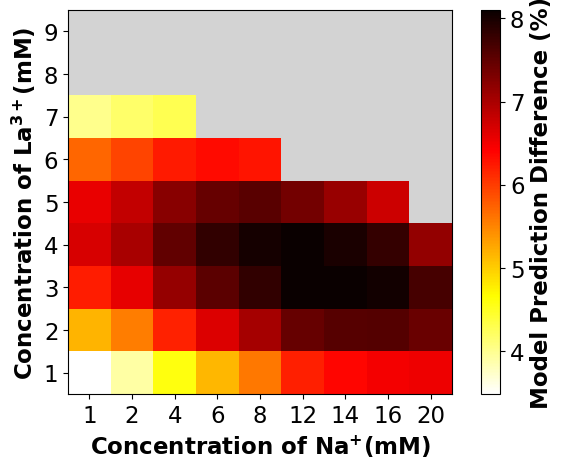

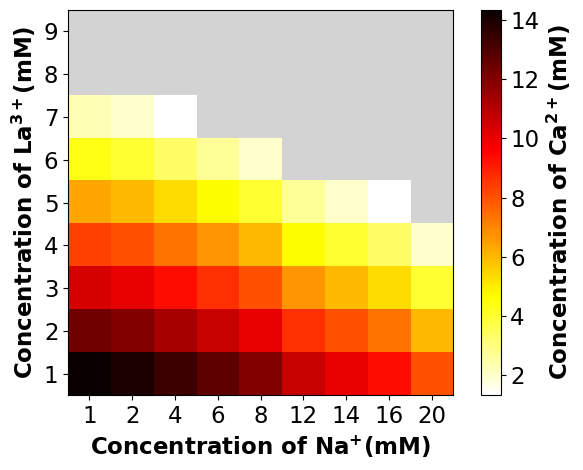

In [32]:
# desired ionic strength in mM
ionic_strength_50 = 50

# cation concentration in mM
# na_50 = [1, 2, 4, 6, 8, 10]
# la_50 = [6, 5, 4, 3, 2, 1]
na_50 = [1, 2, 4, 6, 8, 12, 14, 16, 20]
la_50 = [9, 8, 7, 6, 5, 4, 3, 2, 1]

three_salts_conc(la_50, na_50, ionic_strength_50, "ionic_str_50")

### 100 mM Ionic Strength

The concentration of NaCl is: 4
The concentration of LaCl3 is: 16
The concentration of CaCl2 is: 0.0
The concentration of NaCl is: 4
The concentration of LaCl3 is: 14
The concentration of CaCl2 is: 4.0
Relaxation correction: [-0.12043329 -0.0484649  -0.01285613 -0.10180263]
Hydrodynamic correction: [-0.32737806 -0.25973342 -0.15395153 -0.09481732]
omega_bar: 249826864991.60953
Alpha: [0.0, 186572897565.1567, 308668402701.2538, 366828591024.95044]
Mew: [0.63 0.08 0.02 0.27]
Transport number: [0.37910854 0.06159529 0.02593691 0.53335926]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.45584564 -0.5317497  -0.33920814 -0.34707432]
 [ 1.13783895  3.79310969 -0.5412421  -0.5096123 ]
 [ 0.67553857  0.1994168   5.48198382 -2.82963451]
 [ 0.44348841  0.10209333  0.54578081  1.17043887]]
The MAPE is of (4, 14) 5.301159769954976
The concentration of NaCl is: 4
The concentration of LaCl3 is: 12
The concentration of CaCl2 is: 8.0
Relaxation correction: [-0.1278413  -

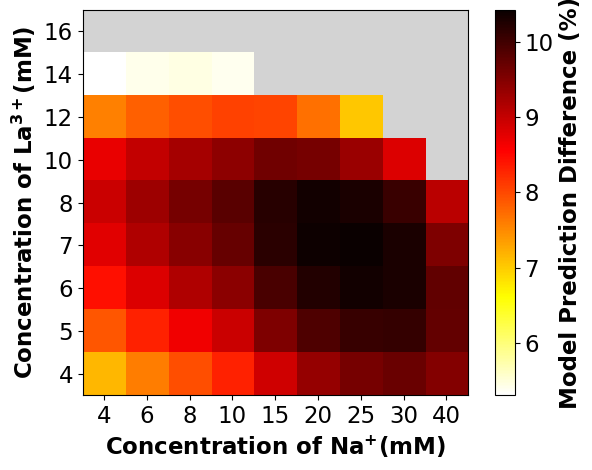

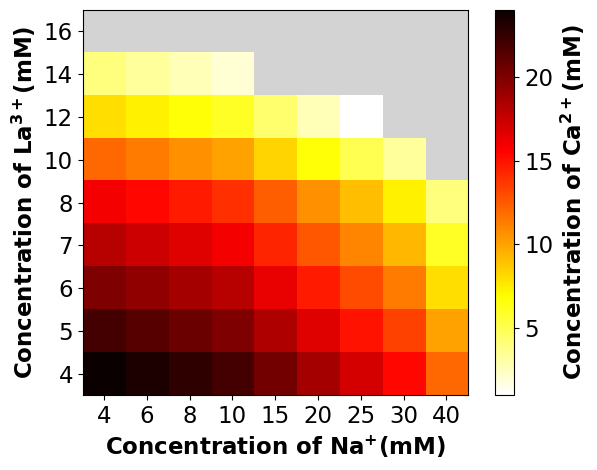

In [25]:
# data in mM
ionic_strength_100 = 100

# cation concentration in mM
# na_100 = [4, 8, 10, 12, 15, 20]
# la_100 = [12, 10, 8, 6, 5, 4]
na_100 = [4, 6, 8, 10, 15, 20, 25, 30, 40]
la_100 = [16, 14, 12, 10, 8, 7, 6, 5, 4]

three_salts_conc(la_100, na_100, ionic_strength_100, "ionic_str_100")

### 150 mM Ionic Strength

The concentration of NaCl is: 8
The concentration of LaCl3 is: 24
The concentration of CaCl2 is: -0.6666666666666666
The concentration of NaCl is: 8
The concentration of LaCl3 is: 20
The concentration of CaCl2 is: 7.333333333333333
Relaxation correction: [-0.13825022 -0.05705681 -0.01567653 -0.11198297]
Hydrodynamic correction: [-0.38330317 -0.30492643 -0.18068274 -0.11012006]
omega_bar: 253638014247.945
Alpha: [0.0, 185177783333.67725, 304812137764.90094, 368754461556.5953]
Mew: [0.6        0.09777778 0.02666667 0.27555556]
Transport number: [0.35563055 0.07415194 0.03406291 0.5361546 ]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.47761339 -0.61553375 -0.37304143 -0.33245131]
 [ 1.15485188  3.39918756 -0.60021643 -0.48724275]
 [ 0.68563919  0.21940933  4.68810217 -2.6193325 ]
 [ 0.45011943  0.11287862  0.57156034  1.1502623 ]]
The MAPE is of (8, 20) 7.151885971267952
The concentration of NaCl is: 8
The concentration of LaCl3 is: 18
The concentration o

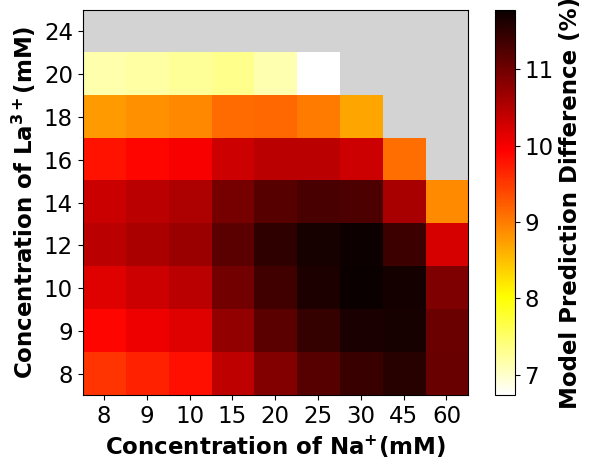

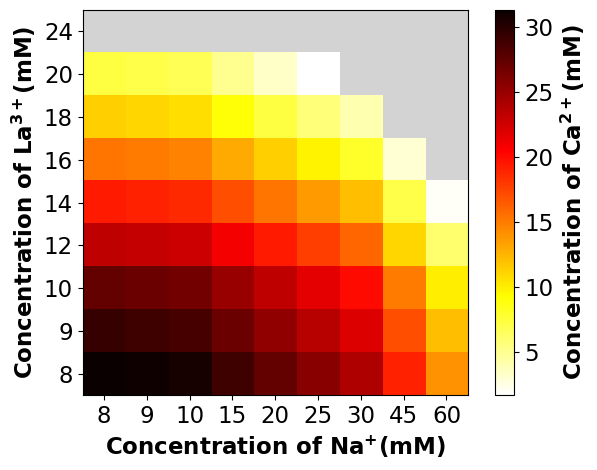

In [24]:
# desired ionic strength in mM
ionic_strength_150 = 150

# cation concentration in mM
# na_150 = [8, 10, 12, 15, 20, 25]
# la_150 = [14, 12, 10, 8, 6, 5]
na_150 = [8, 9, 10, 15, 20, 25, 30, 45, 60]
la_150 = [24, 20, 18, 16, 14, 12, 10, 9, 8]

three_salts_conc(la_150, na_150, ionic_strength_150, "ionic_str_150")

### 200 mM Ionic Strength

The concentration of NaCl is: 12
The concentration of LaCl3 is: 32
The concentration of CaCl2 is: -1.3333333333333333
The concentration of NaCl is: 12
The concentration of LaCl3 is: 28
The concentration of CaCl2 is: 6.666666666666667
Relaxation correction: [-0.1456693  -0.05954095 -0.0161334  -0.12094849]
Hydrodynamic correction: [-0.42656354 -0.34006395 -0.20145394 -0.12179248]
omega_bar: 252147070422.88983
Alpha: [0.0, 187375116922.66306, 302510733605.00964, 369845227275.9801]
Mew: [0.63       0.06666667 0.03       0.27333333]
Transport number: [0.37562006 0.05085709 0.03854736 0.53497549]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.4670554  -0.49693421 -0.39561194 -0.32643631]
 [ 1.14660012  4.20837116 -0.63987413 -0.47793659]
 [ 0.6807401   0.19175945  4.36671127 -2.52463189]
 [ 0.44690319  0.09789399  0.58863095  1.14605952]]
The MAPE is of (12, 28) 6.563720767286197
The concentration of NaCl is: 12
The concentration of LaCl3 is: 24
The concentra

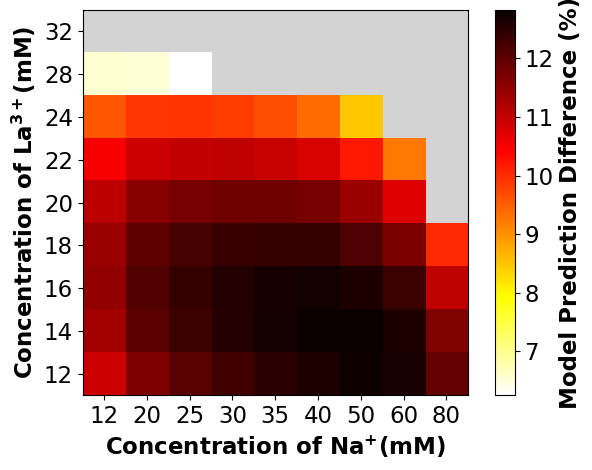

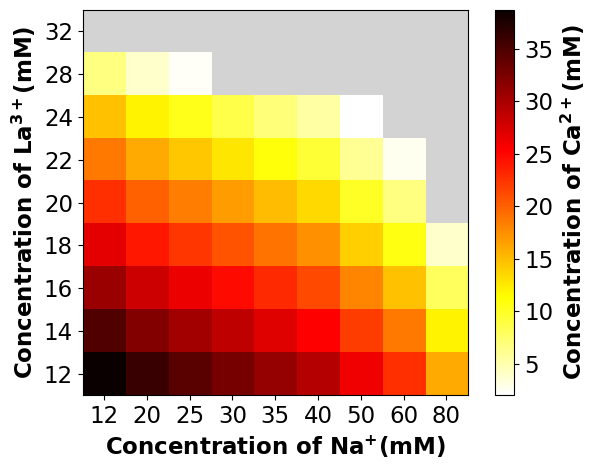

In [21]:
# desired ionic strength in mM
ionic_strength_200 = 200

# cation concentration in mM
# na_200 = [10, 12, 15, 20, 25, 30]
# la_200 = [16, 14, 12, 10, 8, 6]

na_200 = [12, 20, 25, 30, 35, 40, 50, 60, 80]
la_200 = [32, 28, 24, 22, 20, 18, 16, 14, 12]

three_salts_conc(la_200, na_200, ionic_strength_200, "ionic_str_200")

## Validate the Optimal Experiments

In [16]:
three_salts = pd.read_csv("./Data/Na_Ca_La_cond.csv")
NaCl_conc_three_salts = three_salts["NaCl Conc"]
CaCl2_conc_three_salts = three_salts["CaCl2 Conc"]
LaCl3_conc_three_salts = three_salts["LaCl3 Conc"]
three_salts_cond_raw = three_salts["Cond"]

# get the number of data
ndata_three_salts = len(NaCl_conc_three_salts)

# convert the conductivity from micro.S/cm to milli.S/cm
three_salts_cond = [three_salts_cond_raw[i] * 10**(-3) for i in range(ndata_three_salts)]

In [17]:
# evaluate the salts concentration in M using the cation ratio
conc_NaCl_shed_three = [NaCl_conc_three_salts[i] * 10**(-3) for i in range(ndata_three_salts)]
conc_CaCl2_shed_three = [CaCl2_conc_three_salts[i] * 10**(-3) for i in range(ndata_three_salts)]
conc_LaCl3_shed_three = [LaCl3_conc_three_salts[i] * 10**(-3) for i in range(ndata_three_salts)]

# calculate the individual salt conductivity using the variant Shedlovsky model
variant_shed_cond_NaCl_3 = cd.variant_shedlovsky(conc_NaCl_shed_three, temp, epsilon, eta_shed, lambda_0_NaCl, a_Na_Ca_La, z_Na, z_Cl, 
                             lambda_0_Na, lambda_0_Cl)
variant_shed_cond_CaCl2_3 = cd.variant_shedlovsky(conc_CaCl2_shed_three, temp, epsilon, eta_shed, lambda_0_CaCl2, a_Na_Ca_La, z_Ca, z_Cl, 
                             lambda_0_Ca, lambda_0_Cl)
variant_shed_cond_LaCl3_3 = cd.variant_shedlovsky(conc_LaCl3_shed_three, temp, epsilon, eta_shed, lambda_0_LaCl3, a_Na_Ca_La, z_La, z_Cl, 
                             lambda_0_La, lambda_0_Cl)

# calculate the bulk conductivity using the variant Shedlovsky model
variant_shed_cond_3 = [variant_shed_cond_NaCl_3[i] + variant_shed_cond_CaCl2_3[i] + variant_shed_cond_LaCl3_3[i] for i in range(ndata_three_salts)]

# calculate the bulk conductivity using the MSA transport model
msa_cond_3 = cd.msa_transport(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon, lambda_0_La_Ca_Na_Cl, 
                            LaCl3_conc_three_salts, CaCl2_conc_three_salts, NaCl_conc_three_salts)

Relaxation correction: [-0.18717426 -0.09126877 -0.03053849 -0.09855933]
Hydrodynamic correction: [-0.42685723 -0.34029852 -0.20159288 -0.12187565]
omega_bar: 297964651192.6128
Alpha: [0.0, 171591196388.40176, 267580927290.05347, 383159251460.6761]
Mew: [0.315 0.22  0.125 0.34 ]
Transport number: [0.15893076 0.14202167 0.13591663 0.56313093]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.74819456 -1.66435744 -0.63511193 -0.24982198]
 [ 1.36632883  1.92855413 -1.15077439 -0.36155442]
 [ 0.81119373  0.3249792   2.0098855  -1.59817546]
 [ 0.53254549  0.1746126   0.59410276  1.0529642 ]]


In [18]:
# calculate the ionic strength of the experiments
def ionic_strength(salt_1_conc, salt_2_conc, salt_3_conc, valency):
    """ Calculates the ionic strength of the salt solution

        Arguments:
            salt_conc_1: list or Pandas series of the concentration of the highest valency salt in mM
            salt_conc_2: list or Pandas series of the concentration of the second highest valency salt in mM
            salt_conc_3: list or Pandas series of the concentration of the lowest valency salt in mM
            valency: list of the valency of ions in decreasing order

        Returns:
            ionic_strength: ionic strength of the salt solution
    """
    # calculate the species concentration
    ndata = len(salt_1_conc)
    cation_1_conc = salt_1_conc
    cation_2_conc = salt_2_conc
    cation_3_conc = salt_3_conc
    anion_conc = [valency[0] * salt_1_conc[i] + valency[1] * salt_2_conc[i] + valency[2] * salt_3_conc[i] for i in range(ndata)]
    n_species = len(valency)
    
    # calculate the ionic stength of the solution
    ionic_strength = []
    for i in range(ndata):
        ion_conc = [cation_1_conc[i], cation_2_conc[i], cation_3_conc[i], anion_conc[i]]
        ionic_strength.append(0.5 * sum(ion_conc[j] * valency[j] ** 2 for j in range(n_species)))

    return ionic_strength

# calculate the ionic strengths
ionic_strength_na_ca_la = ionic_strength(LaCl3_conc_three_salts, CaCl2_conc_three_salts, NaCl_conc_three_salts, valency)
print(ionic_strength_na_ca_la)

[50.0, 100.0, 150.0, 200.0]


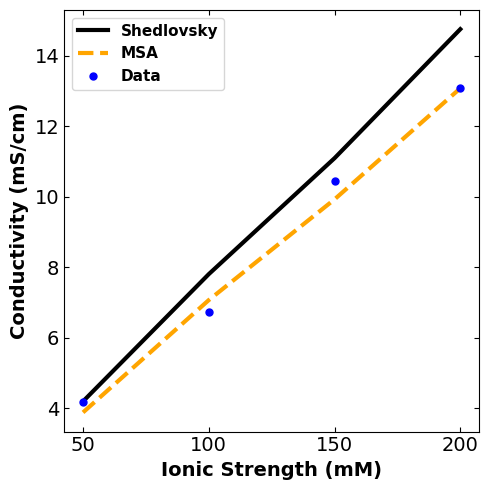

In [19]:
# make plot comparison of the model predictions and the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_ca_la, variant_shed_cond_3, "-", color="black", linewidth=3, label="Shedlovsky")
plt.plot(ionic_strength_na_ca_la, msa_cond_3, "--", linewidth=3, color="orange", label="MSA")
plt.plot(ionic_strength_na_ca_la, three_salts_cond, "b.", markersize=10, label="Data")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=14,fontweight='bold')
plt.xticks([50, 100, 150, 200], fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight": "bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Paper_figures\var_shed_msa_na_ca_la.png")
plt.show()

The mean absolute percent error is: 8.77301147437318
The mean absolute percent error is: 4.3768188940822625

The mean absolute error is: 0.8497227093729542
The mean absolute error is: 0.2950503597180629

The mean squared error is: 1.0956262513361295
The mean squared error is: 0.12337457347293462


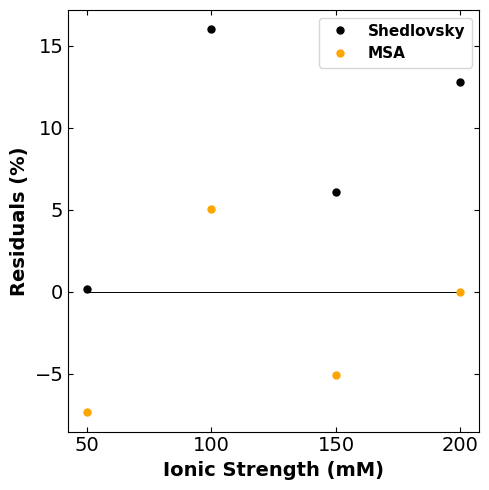

In [20]:
# calculate the residuals
e_three_salts_shed = [variant_shed_cond_3[i] - three_salts_cond[i] for i in range(ndata_three_salts)]
e_three_salts_msa = [msa_cond_3[i] - three_salts_cond[i] for i in range(ndata_three_salts)]

# residuals fraction
residuals_percent_shed_3 = [100*e_three_salts_shed[i]/three_salts_cond[i] for i in range(ndata_three_salts)]
residuals_percent_msa_3 = [100*e_three_salts_msa[i]/three_salts_cond[i] for i in range(ndata_three_salts)]

# zero residual line
zero_residuals = [0, 0, 0, 0]

# calculate the mean absolute percent error
residuals_percent_shed_3_abs = [np.abs(residuals_percent_shed_3[i]) for i in range(ndata_three_salts)]
residuals_percent_msa_3_abs = [np.abs(residuals_percent_msa_3[i]) for i in range(ndata_three_salts)]
print("The mean absolute percent error is:",np.mean(residuals_percent_shed_3_abs))
print("The mean absolute percent error is:",np.mean(residuals_percent_msa_3_abs))

# calculate the mean absolute error
residuals_abs_shed_3 = [np.abs(e_three_salts_shed[i]) for i in range(ndata_three_salts)]
residuals_abs_msa_3 = [np.abs(e_three_salts_msa[i]) for i in range(ndata_three_salts)]
print("\nThe mean absolute error is:",np.mean(residuals_abs_shed_3))
print("The mean absolute error is:",np.mean(residuals_abs_msa_3))

# calculate the mean squared error
sq_residuals_shed_3 = [e_three_salts_shed[i]**2 for i in range(ndata_three_salts)]
sq_residuals_msa_3 = [e_three_salts_msa[i]**2 for i in range(ndata_three_salts)]
print("\nThe mean squared error is:",np.mean(sq_residuals_shed_3))
print("The mean squared error is:",np.mean(sq_residuals_msa_3))

# make plot comparison of the model errors
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_ca_la, zero_residuals, "-", color="black", linewidth=0.7)
plt.plot(ionic_strength_na_ca_la, residuals_percent_shed_3, ".", color="black", markersize=10, label="Shedlovsky")
plt.plot(ionic_strength_na_ca_la, residuals_percent_msa_3, ".", markersize=10, color="orange", label="MSA")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks([50, 100, 150, 200], fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight": "bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Paper_figures\var_shed_msa_na_ca_la_resid.png")
plt.show()